<a href="https://colab.research.google.com/github/Haruharu-hub/hazard-project/blob/main/feedback_loop_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Configuration

In [ ]:
model_name = "llava"         # "llava", "llavanext", "llamavision", "llavacot"
batch_size = 0               # set 0 for sample-level feedback; or set between (1, 30) equivalent to (50, 1500) samples in train set
template_id = 'r1'
run_set = 'train'
run_feedback_loop = True
domain = 'Traffic'
root_dir = '/content/drive/MyDrive/'
save_dir = f'{root_dir}/results'

Install

In [ ]:
# @title
%%capture
!pip install json-repair
!pip install --upgrade transformers

Import

In [ ]:
# @title
%%capture
import time
import pandas as pd
from tqdm.notebook import tqdm

import torch
from PIL import Image
from transformers import LlavaForConditionalGeneration, LlavaNextForConditionalGeneration, MllamaForConditionalGeneration, AutoProcessor

import re
import ast
from json_repair import repair_json

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report
from collections import defaultdict

from google.colab import drive
drive.mount('/content/drive')

from IPython.display import HTML, display, clear_output
def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)

import os

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

Model

In [ ]:
# @title
%%capture
if model_name == "llava":
    model_id = "llava-hf/llava-1.5-7b-hf"
    model = LlavaForConditionalGeneration.from_pretrained(model_id, device_map="auto", dtype=torch.float16)
    assistant_token = 'ASSISTANT:'

elif model_name == "llavanext":
    model_id = "llava-hf/llava-v1.6-mistral-7b-hf"
    model = LlavaNextForConditionalGeneration.from_pretrained(model_id, device_map="auto", dtype=torch.float16)
    assistant_token = '[/INST]'

elif model_name== "llamavision":
    model_id = "meta-llama/Llama-3.2-11B-Vision-Instruct"
    model = MllamaForConditionalGeneration.from_pretrained(model_id, device_map="auto", dtype=torch.float16)
    assistant_token = '<|eot_id|><|start_header_id|>assistant<|end_header_id|>'

elif model_name == "llavacot":
    model_id = "Xkev/Llama-3.2V-11B-cot"
    model = MllamaForConditionalGeneration.from_pretrained(model_id, device_map="auto", dtype=torch.float16)
    assistant_token = '<|eot_id|><|start_header_id|>assistant<|end_header_id|>'

model.tie_weights()
processor = AutoProcessor.from_pretrained(model_id, use_fast=True)
processor.tokenizer.padding_side = "left"


Rules

In [ ]:
# @title
rule_description = {

"Construction": {

"Ladder Use" : """Ladder Use:
* Ladders shall be used only on stable and level surfaces unless secured to prevent accidental displacement. [1926.1053(b)(6)]
* The area around the top and bottom of ladders shall be kept clear. [1926.1053(b)(9)]
* When ascending or descending a ladder, the user shall face the ladder. [1926.1053(b)(20)]
* Each employee shall use at least one hand to grasp the ladder when progressing up and/or down the ladder. [1926.1053(b)(21)]
* An employee shall not carry any object or load that could cause the employee to lose balance and fall. [1926.1053(b)(22)]""",

"Protective Equipment": """Protective Equipment:
* Employees working in areas where there is a possible danger of head injury from impact, or from falling or flying objects, or from electrical shock and burns, shall be protected by protective helmets. [1926.100(a)]
* Each affected employee uses appropriate eye or face protection when exposed to eye or face hazards from flying particles, molten metal, liquid chemicals, acids or caustic liquids, chemical gases or vapors, or potentially injurious light radiation. [1926.102(a)(1)]
* Each employee on a walking/working surface (horizontal and vertical surface) with an unprotected side or edge which is 6 feet (1.8 m) or more above a lower level shall be protected from falling by the use of guardrail systems, safety net systems, or personal fall arrest systems. [1926.501(b)(1)]""",

"Fire Risk" : """Fire Safety:
* Smoking shall be prohibited at or in the vicinity of operations which constitute a fire hazard, and shall be conspicuously posted: "No Smoking or Open Flame." [1926.151(a)(3)]
* If the object to be welded, cut, or heated cannot be moved and if all the fire hazards cannot be removed, positive means shall be taken to confine the heat, sparks, and slag, and to protect the immovable fire hazards from them. [1926.352(b)]""",

"Crane Use" : """Crane Use:
* The operator must not engage in any practice or activity that diverts his/her attention while actually engaged in operating the equipment, such as the use of cellular phones (other than when used for signal communications). [1926.1417(d)]
* Erect and maintain control lines, warning lines, railings or similar barriers to mark the boundaries of the hazard areas. [1926.1424(a)(2)(ii)]
* While the operator is not moving a suspended load, no employee must be within the fall zone [1926.1425(b)]""",

"Scaffolding Risk" : """Scaffold Safety:
* Each platform on all working levels of scaffolds shall be fully planked or decked between the front uprights and the guardrail supports [1926.451(b)(1)]
* Guardrail systems shall be installed along all open sides and ends of platforms. [1926.451(g)(4)]
* The top edge height of toprails or equivalent member on supported scaffolds shall be installed between 38 inches (0.97 m) and 45 inches (1.2 m) above the platform surface. [1926.451(g)(4)(ii)]
* In addition to wearing hardhats each employee on a scaffold shall be provided with additional protection from falling hand tools, debris, and other small objects through the installation of toeboards, screens, or guardrail systems, or through the erection of debris nets, catch platforms, or canopy structures that contain or deflect the falling objects. [1926.451(h)(1)]""",
},

"Warehouse" : {

"Surface Condition" : """Surface Condition:
* All places of employment, passageways, storerooms, service rooms, and walking-working surfaces are kept in a clean, orderly, and sanitary condition. [29 CFR 1910.22(a)(1)]
* The floor of each workroom is maintained in a clean and, to the extent feasible, in a dry condition. When wet processes are used, drainage must be maintained and, to the extent feasible, dry standing places, such as false floors, platforms, and mats must be provided. [29 CFR 1910.22(a)(2)]
* Walking-working surfaces are maintained free of hazards such as sharp or protruding objects, loose boards, corrosion, leaks, spills, snow, and ice. [29 CFR 1910.22(a)(3)]""",

"Ergonomic Lifting" : """Ergonomic Lifting:
* Safe lifting involves: Holding the load close to your body at waist height. Never lift a heavy item above shoulder level. Never carry a load that obstructs your vision. [General Duty Clause, Section 5(a)(1)]
* The following points should be considered: The start and finish height of the load should be a suitable level above the floor, that is, between mid-thigh to shoulder height, preferably at about waist height. The back should not be twisted or bent sideways. Lifting with one hand should be avoided. [NOHSC:2005(1990) 5.66] """,

"Protective Equipment": """Protective Equipment:
* Each affected employee uses appropriate eye or face protection when exposed to eye or face hazards from flying particles, molten metal, liquid chemicals, acids or caustic liquids, chemical gases or vapors, or potentially injurious light radiation [29 CFR 1910.133(a)(1)]
* each affected employee wears a protective helmet when working in areas where there is a potential for injury to the head from falling objects. [29 CFR 1910.135(a)(1)]
* Personal fall protection systems must be worn with the attachment point of the body harness located in the center of the employee's back near shoulder level. The attachment point may be located in the pre-sternal position if the free fall distance is limited to 2 feet (0.6 m) or less. [29 CFR 1910.140(c)(22)]""",

"Ladder Use" : """Ladder Use:
* Ladders are used only on stable and level surfaces; [29 CFR 1910.23(c)(4)]
* Each employee faces the ladder when climbing up or down it; [29 CFR 1910.23(b)(11)]
* Each employee uses at least one hand to grasp the ladder when climbing up and down it; and [29 CFR 1910.23(b)(12)]
* No employee carries any object or load that could cause the employee to lose balance and fall while climbing up or down the ladder. [29 CFR 1910.23(b)(13)]""",

"Forklift Use" : """Forklift Use:
* No person shall be allowed to stand or pass under the elevated portion of any truck, whether loaded or empty. [29 CFR 1910.178(m)(2)]
* All traffic regulations shall be observed, including authorized plant speed limits. A safe distance shall be maintained approximately three truck lengths from the truck ahead, and the truck shall be kept under control at all times. [1910.178(n)(1)]
* The driver shall be required to look in the direction of, and keep a clear view of the path of travel. [1910.178(n)(6)]""",
},

"Traffic": {

"Driving Distraction" : """Driver Control:
* Distracted driving: Distracted driving is any activity that diverts attention from driving, including talking or texting on your phone, eating and drinking, talking to people in your vehicle, fiddling with the stereo, entertainment or navigation system — anything that takes your attention away from the task of safe driving. [National Highway Traffic Safety Administration]
* Driver to have proper control of a vehicle etc.: A person must not drive a vehicle if a person or an animal is in the driver's lap. [ROAD SAFETY ROAD RULES 2017 - REG 297 (1A)]
* Touching or looking at portable devices in motor vehicles: The driver of a motor vehicle must not touch a portable device in the motor vehicle while the vehicle is moving, or is stationary but not parked. [ROAD SAFETY ROAD RULES 2017 - REG 304J (1)]
* Duty of driver to avoid driving while fatigued: A person must not drive a fatigue-regulated heavy vehicle on a road while the person is impaired by fatigue. [HEAVY VEHICLE NATIONAL LAW (ACT) - SECT 228 (1)]""",

"Traffic Rules" : """Road Rules:
* Giving way at a pedestrian crossing: A driver must give way to any pedestrian on or entering a pedestrian crossing. [ROAD SAFETY ROAD RULES 2017 - REG 81 (2)]
* Overtaking or passing a vehicle at a children's crossing or pedestrian crossing: A driver approaching a children's crossing, or pedestrian crossing, must not overtake or pass a vehicle that is travelling in the same direction as the driver and is stopping, or has stopped, to give way to a pedestrian at the crossing. [ROAD SAFETY ROAD RULES 2017 - REG 82]
* Proceeding through a red traffic light: If traffic lights at an intersection or marked foot crossing are showing a red traffic light, a driver must not enter the intersection or marked foot crossing. [ROAD SAFETY ROAD RULES 2017 - REG 59]
* Driving on a one-way service road: A driver on the part of the road that is a service road must drive in the same direction as a vehicle travelling on the part of the road closest to the service road is required to travel. [ROAD SAFETY ROAD RULES 2017 - REG 136]
* Opening doors and getting out of a vehicle etc.: A person must not cause a hazard to any person or vehicle by opening a door of a vehicle, leaving a door of a vehicle open, or getting off, or out of, a vehicle. [ROAD SAFETY ROAD RULES 2017 - REG 269 (3)]
* Driving within a single marked lane or line of traffic: A driver on a multi-lane road must drive so the driver's vehicle is completely in a marked lane [ROAD SAFETY ROAD RULES 2017 - REG 146 (1)]
* Emergency stopping lane only signs: A driver must not drive in an emergency stopping lane. [ROAD SAFETY ROAD RULES 2017 - REG 95 (1)]
* Stopping in an emergency stopping lane: A driver must not stop in an emergency stopping lane. [ROAD SAFETY ROAD RULES 2017 - REG 178]
* Parking in parking bays: A driver must position the driver's vehicle completely within a single parking bay. [ROAD SAFETY ROAD RULES 2017 - REG 211 (2)]
* Obstructing access to and from a footpath, driveway etc.: A driver must not stop on a road in a position that obstructs access by vehicles or pedestrians to or from a footpath ramp or a similar way of access to a footpath, or a bicycle path or passageway. [ROAD SAFETY ROAD RULES 2017 - REG 198 (1)]""",

"Pedestrian Crossing" : """Pedestrian Rules:
* Crossing a road—general: A pedestrian crossing a road— (a) must cross by the shortest safe route; and (b) must not stay on the road longer than necessary to cross the road safely. [ROAD SAFETY ROAD RULES 2017 - REG 230 (1)]
* Crossing a road at pedestrian lights: If the pedestrian lights show a red pedestrian light and the pedestrian has not already started crossing the intersection or road, the pedestrian must not start to cross until the pedestrian lights change to green. [ROAD SAFETY ROAD RULES 2017 - REG 231 (2)]
* Pedestrians not to cause a traffic hazard or obstruction: A pedestrian must not cause a traffic hazard by moving into the path of a driver. [ROAD SAFETY ROAD RULES 2017 - REG 236 (1)]""",

"Road Condition" : """Driving Conditions:
* Obligations of road users: A person who drives a motor vehicle on a highway must drive in a safe manner having regard to all the relevant factors. [ROAD SAFETY ACT 1986 - SECT 17A (1)]
* The relevant factors include the following— (a) the physical characteristics of the road; (b) the prevailing weather conditions; (c) the level of visibility; (d) the condition of any vehicle the person is driving or riding on the highway; (e) the prevailing traffic conditions; (f) the relevant road laws and advisory signs; (g) the physical and mental condition of the driver or road user. [ROAD SAFETY ACT 1986 - SECT 17A (2A)]
* Relevant vehicle not to be used in hazardous area without hazardous area authority: A person must not use a relevant vehicle in a hazardous area. [ROAD SAFETY (VEHICLES) REGULATIONS 2021 - REG 299]""",

"Vehicle Load": """Vehicle Load:
* Carrying goods in addition to a large indivisible items: A load-carrying vehicle must not carry more than 1 large indivisible item. [HEAVY VEHICLE (MASS, DIMENSION AND LOADING) NATIONAL REGULATION - SCHEDULE 8 Division 2 - Load-carrying vehicles 13 (1)]
* Load restraint requirement: The following requirements apply to a vehicle that is carrying a load— (a) the load must be secured by a means that is appropriate to the vehicle and the nature of the load; (b) the load must be placed and secured on the vehicle in a way that prevents, or would be likely to prevent, the load or any part of the load from— (i) hanging or projecting from the vehicle; or (ii) becoming dislodged or falling from the vehicle; (c) the load must not be placed or secured on the vehicle in a way that makes the vehicle unstable; (d) the load must be placed and secured on the vehicle in compliance with the performance standards recommended in the Load Restraint Guide for Light Vehicles 2018, published by the National Transport Commission. [ROAD SAFETY (VEHICLES) REGULATIONS 2021 - REG 285]""",
}
}

custom_rules = rule_description[domain]


Prompt

In [ ]:
RULE_TEMPLATE = "coded-rules" # 'bulletpoints', 'bulletpoints-with-header', 'coded-rules'

META_PROMPT_TEMPLATE = """
{instruction_text}

{safety_rules}{augmented_context}

{response_format}"""

templates = {

## JSON classification explanation

"r1": {
    "instruction_text": """Analyze the image against the rule set. If the rule set clearly applies to the scenario depicted, determine whether it is "Complied" or "Violated". If the rule set does not clearly apply, return "Not Applicable".""",
    "augmented_context": "",
    "response_format": """Think step-by-step before giving your final answer. Respond only with a JSON object containing the following keys:
  - "classification": one of "Complied", "Violated", or "Not Applicable".
  - "explanation": an explanation for the classification made.
  - "confidence": a numeric value between 0 and 1 estimating both the likelihood that the classification is correct and how free it is from ambiguity.""",
 },

# Amanda's prompt
"r4": {
  "instruction_text": """
  - Analyze the image against the rule set.
  - ONLY describe what you can clearly see in the image, and treat anything outside the frame as unknown.
  - Use object detection, pose estimation, and spatial awareness to confirm what's happening.
  - If the rule set clearly applies to the scenario depicted, determine the state of compliance. Otherwise (including if unsure), state "Not Applicable".
  - If you would need to invent, infer, or guess to decide (e.g., object partially occluded, identity ambiguous, or evidence unclear), classify as "Not Applicable".""",
    "augmented_context": "",
    "response_format": """Respond only with a JSON object containing exactly these keys:
  - "classification": one of "Complied", "Violated", or "Not Applicable"
  - "explanation": a concise explanation for the classification made
  - "confidence": a numeric confidence (0 to 1) that your classification is correct""",
},
}



Helper Functions

In [ ]:
# @title
import re
import json

def parse_ruleset(raw_text, ruleset_id="RS-1"):
    lines = raw_text.strip().splitlines()
    ruleset_title = lines[0].rstrip(":").strip()
    rule_lines = [line.strip() for line in lines[1:] if line.strip()]

    rules = []
    rule_id_counter = 1

    for line in rule_lines:
        match = re.match(r"^\* (.*?):\s*(.*?)\s*\[(.*?)\]$", line)
        if match:
            title, definition, source = match.groups()
        else:
            source_match = re.search(r"\[(.*?)\]$", line)
            source = source_match.group(1) if source_match else "Unknown"
            definition = re.sub(r"^\*\s*", "", line)
            definition = re.sub(r"\s*\[.*?\]$", "", definition).strip()
            title = "General rule"

        rules.append({
            "ID": f"{ruleset_id}.{rule_id_counter}",
            "Title": title.strip(),
            "Definition": definition.strip(),
            "Source": source.strip()
        })
        rule_id_counter += 1

    ruleset = {
        "Rule Set": {
            "ID": ruleset_id,
            "Title": ruleset_title,
            "Rules": rules
        }
    }
    return ruleset

def json_to_ruleset(ruleset_json, indent_spaces = 2):
    ruleset = ruleset_json["Rule Set"]
    rule_lines = [f"Rule Set: {ruleset['Title']} (ID: {ruleset['ID']})"]
    indent = " " * indent_spaces

    for rule in ruleset["Rules"]:
        rule_lines.append(f"{indent}Rule ID: {rule['ID']}")
        rule_lines.append(f"{indent*indent_spaces}Title: {rule['Title']}")
        rule_lines.append(f"{indent*indent_spaces}Definition: {rule['Definition']}")
        rule_lines.append(f"{indent*indent_spaces}Source: {rule['Source']}")

    return "\n".join(rule_lines)

def get_template(template_id, rule_key, feedbacks = None, rule_template = RULE_TEMPLATE):

    temp = templates.get(template_id)
    instruction_text = temp.get('instruction_text')
    augmented_context = temp.get('augmented_context')

    if feedbacks:
        augmented_context = "\n\nMeta-rules: \n"
        augmented_context += "\n".join(feedbacks.get('general', ['']))
        if feedbacks.get(rule_key, ''):
            augmented_context += "\n".join(feedbacks.get(rule_key, ['']))

    response_format = temp.get('response_format')

    if rule_template == 'bulletpoints':

        if isinstance(rule_key, list):
            ruleset_text = "Rule Set: \n\n"
            for i, r in enumerate(rule_key, start=1):
                safety_rules = custom_rules[r].strip()
                rule_name = safety_rules.split(':\n')[0].strip()
                rule_description = safety_rules[len(safety_rules.split(':\n')[0])+1:]
                ruleset_text += rule_description
                ruleset_text += "\n\n"

        elif rule_key == 'all':
            ruleset_text = "Rule Set: \n\n"
            for i, (k, v) in enumerate(custom_rules.items(), start = 1):
                safety_rules = v.strip()
                rule_name = safety_rules.split(':\n')[0].strip()
                rule_description = safety_rules[len(safety_rules.split(':\n')[0])+1:]
                ruleset_text += rule_description
                ruleset_text += "\n\n"
        else:
            safety_rules = custom_rules[rule_key].strip()
            rule_name = safety_rules.split(':\n')[0].strip()
            rule_description = safety_rules[len(safety_rules.split(':\n')[0])+1:]
            ruleset_text = f'Rule Set: {rule_description}"'

    elif rule_template == 'bulletpoints-with-header':

        if isinstance(rule_key, list):
          ruleset_text = "Rule Set: \n\n"
          for i, r in enumerate(rule_key, start=1):
              safety_rules = custom_rules[r].strip()
              rule_name = safety_rules.split(':\n')[0].strip()
              rule_description = safety_rules[len(safety_rules.split(':\n')[0])+1:]
              ruleset_text += f'{i}. Rule: "{rule_name}" \nRelevant Sub-Rules: {rule_description}"'
              ruleset_text += "\n\n"

        elif rule_key == 'all':
            ruleset_text = "Rule Set: \n\n"
            for i, (k, v) in enumerate(custom_rules.items(), start = 1):
                safety_rules = v.strip()
                rule_name = safety_rules.split(':\n')[0].strip()
                rule_description = safety_rules[len(safety_rules.split(':\n')[0])+1:]
                ruleset_text += f'{i}. Rule: "{rule_name}" \nRelevant Sub-Rules: {rule_description}"'
                ruleset_text += "\n\n"
        else:
            safety_rules = custom_rules[rule_key].strip()
            rule_name = safety_rules.split(':\n')[0].strip()
            rule_description = safety_rules[len(safety_rules.split(':\n')[0])+1:]
            ruleset_text = f'Rule Set: "{rule_name}" \nRelevant Sub-Rules: {rule_description}"'

    elif rule_template == 'coded-rules':

        if isinstance(rule_key, list):
            ruleset_text = []
            for i, r in enumerate(rule_key, start=1):
                safety_rules = custom_rules[r].strip()
                ruleset_json = parse_ruleset(safety_rules, ruleset_id=f"RS-{i}")
                ruleset_text.append(json_to_ruleset(ruleset_json))

            ruleset_text = '\n\n'.join(ruleset_text).strip()

        elif rule_key == 'all':
            ruleset_text = []
            for i, (k, v) in enumerate(custom_rules.items(), start = 1):
                safety_rules = v.strip()
                ruleset_json = parse_ruleset(safety_rules, ruleset_id=f"RS-{i}")
                ruleset_text.append(json_to_ruleset(ruleset_json))

            ruleset_text = '\n\n'.join(ruleset_text).strip()

        else:
            safety_rules = custom_rules[rule_key].strip()
            ruleset_json = parse_ruleset(safety_rules, ruleset_id="RS-1")
            ruleset_text = json_to_ruleset(ruleset_json).strip()

    return META_PROMPT_TEMPLATE.format(instruction_text=instruction_text, safety_rules=ruleset_text,
                                       augmented_context=augmented_context, response_format=response_format)


def load_image(image_path):
    img = Image.open(image_path)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    return img

def flatten_dict(d):
    flat = {}

    def _flatten(obj):
        if isinstance(obj, dict):
            for k, v in obj.items():
                if isinstance(v, dict) or isinstance(v, list):
                    _flatten(v)
                else:
                    flat[k] = v
        elif isinstance(obj, list):
            for item in obj:
                _flatten(item)

    _flatten(d)
    return flat

def extract_json_prediction(raw_pred):
    try:
        prediction = flatten_dict(ast.literal_eval(repair_json(raw_pred)))

    except (ValueError, SyntaxError):
        return 'Unknown', '', -1

    classification = prediction.get('classification', prediction.get('guess', 'Unknown'))
    try:
        reasoning = prediction.get('reasoning', ast.literal_eval(repair_json(raw_pred))['reasoning'])
    except:
        reasoning = ''
    explanation = prediction.get('explanation', '')
    confidence = float(prediction.get('confidence', -1))

    classification = sanitize_pred_label(classification)

    return classification, reasoning, explanation, confidence

def extract_xml_prediction(raw_pred):

    matching = re.search(r"<classification>\s*([^<]*?)\s*(?:</classification>|(?=<))", str(raw_pred), re.DOTALL)
    matching1 = re.search(r"<guess>\s*([^<]*?)\s*(?:</guess>|(?=<))", str(raw_pred), re.DOTALL)

    if matching:
        classification = matching1.group(1).strip()
    elif matching1:
        classification = matching1.group(1).strip()
    else:
        classification = 'Unknown'

    matching2 = re.search(r"<reasoning>(.*?)</reasoning>", str(raw_pred), re.DOTALL)
    matching3 = re.search(r"<explanation>\s*([^<]*?)\s*(?:</explanation>|(?=<))", str(raw_pred), re.DOTALL)
    matching4 = re.search(r"<confidence>\s*([^<]*?)\s*(?:</confidence>|(?=<))", str(raw_pred), re.DOTALL)

    if matching2:
        reasoning = matching2.group(1).strip()
    else:
        reasoning = ''
    if matching3:
        explanation = matching3.group(1).strip()
    else:
        explanation = ''

    if matching4:
        try:
            confidence = float(matching4.group(1).strip())
        except:
            confidence = -1
    else:
        confidence = -1

    classification = sanitize_pred_label(classification)

    return classification, reasoning, explanation, confidence


def sanitize_pred_label(pred_label):

    pred_label = pred_label.replace('Non-Compliant', 'Violated')
    pred_label = pred_label.replace('Compliant', 'Complied')
    pred_label = pred_label.replace('Non-Applicable', 'Not Applicable')

    pred_label = pred_label.strip().title()

    return pred_label if pred_label in ['Complied', 'Violated', 'Not Applicable'] else 'Unknown'

def get_model_outputs(img, template, max_new_tokens = 256):
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": template}]}]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    inputs = processor(text=prompt, images=[img], return_tensors="pt").to(model.device)
    prediction = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        # repetition_penalty=1.2,
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id
    )

    full_pred = processor.decode(prediction[0], skip_special_tokens=False)
    raw_pred = full_pred.split(assistant_token)[-1].replace(processor.tokenizer.eos_token, '').replace(processor.tokenizer.pad_token, '')

    return raw_pred, full_pred


def get_dataset(run_set='all'):

    train_df = pd.read_json(root_dir + f'/experimentation/{domain.lower()}-train.jsonl', lines=True)
    val_df = pd.read_json(root_dir + f'/experimentation/{domain.lower()}-val.jsonl', lines=True)
    test_df = pd.read_json(root_dir + f'/experimentation/{domain.lower()}-test.jsonl', lines=True)

    if run_set == 'all':
        datasets = {'train_df': train_df, 'val_df': val_df, 'test_df': test_df}

    elif run_set == 'train':
        datasets = {'train_df': train_df}

    elif run_set == 'val':
        datasets = {'val_df': val_df}

    elif run_set == 'test':
        datasets = {'test_df': test_df}

    all_unique_images = list(pd.concat(datasets.values())['Image Path'].unique())
    image_cache = {x.replace('data/', ''): load_image(f"{root_dir}{x.replace('data/', '')}") for x in all_unique_images}

    return datasets, image_cache

def create_batch(df, batch_size = 2):

    unique_images = df['Image ID'].unique()
    batches = []

    if batch_size < 1:
        for _, row in df.iterrows():
            batches.append(pd.DataFrame([row]))
        return batches

    remaining_images = list(unique_images)
    while remaining_images:
        current_images = remaining_images[:batch_size]
        batch = df[df['Image ID'].isin(current_images)]
        batches.append(batch)
        remaining_images = remaining_images[batch_size:]

    return batches

def get_answers_from_raw_pred(template_id, raw_pred):

      if template_id.startswith('t'):

          return sanitize_pred_label(raw_pred), '', '', -1

      elif template_id == 'rx1':

          return extract_xml_prediction(raw_pred)

      elif template_id.startswith(('v', 'r')):

          return extract_json_prediction(raw_pred)

import copy

def main(datasets, image_cache, model_name, template_id, domain, run_feedback_loop = True, feedbacks = defaultdict(list), feedback_iteration = "feedback_0", batch_size = 2, early_stop = None, verbose = True):

    for dfname, df in datasets.items():

        print(f"Running {model_name} with on {dfname} set")

        start_time = time.time()

        results = []
        checkpoints = []
        accum_corrections = 0
        accum_revision_error = 0

        max_new_tokens = 1024

        batches = create_batch(df, batch_size)

        for batch_id, batch in tqdm(enumerate(batches), total=len(batches)):

            if batch_id == early_stop:
                break

            log = dict()

            for _, row in tqdm(batch.iterrows(), total=len(batch)):

                domain = row['Domain'].lower()
                filename = row['File']
                image_path = row['Image Path']
                image_id = row['Image ID']
                image_link = row['Image Link']
                rule_key = row['Rule']
                true_label = row['Label']

                raw_pred = ''
                pred_label = 'Unknown'
                pred_reasoning = ''
                pred_explanation = ''
                pred_confidence = -1

                if not image_path.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue

                try:
                    img = image_cache[row['Image Path'].replace('data/', '')]

                    template = get_template(template_id, rule_key, feedbacks)

                    raw_pred, full_pred = get_model_outputs(img, template, max_new_tokens)

                    pred_label, pred_reasoning, pred_explanation, pred_confidence = get_answers_from_raw_pred(template_id, raw_pred)

                    log[image_path+rule_key] = {
                        'Domain': domain,
                        'File': filename,
                        'Image ID': image_id,
                        'Image Path': image_path,
                        'Image Link': image_link,
                        'Rule': rule_key,
                        'Label': true_label,
                        'Pred Init Label': pred_label,
                        'Pred Init Explanation': pred_explanation,
                        'Pred Init Confidence': pred_confidence,
                        'Pred Init Reasoning': pred_reasoning,
                        'Pred Init Full Response': full_pred,
                    }

                except Exception as e:
                    print(f"\nPrediction failed for {image_path}: {e}")
                    print(raw_pred)
                    log[image_path+rule_key] = {
                        'Domain': domain,
                        'File': filename,
                        'Image ID': image_id,
                        'Image Path': image_path,
                        'Image Link': image_link,
                        'Rule': rule_key,
                        'Label': true_label,
                        'Pred Init Label': pred_label,
                        'Pred Init Explanation': pred_explanation,
                        'Pred Init Confidence': pred_confidence,
                        'Pred Init Reasoning': pred_reasoning,
                        'Pred Init Full Response': full_pred,
                    }
                    continue

            if run_feedback_loop == True:

                print(f"Filtering error samples: ...")

                batch_samples = pd.DataFrame(list(log.values()))

                condition1 = (batch_samples['Pred Init Label'] != batch_samples['Label'])
                # condition2 = (batch_samples['Pred Init Confidence'] < 0.5)
                # condition3 = (batch_samples['Pred Init Confidence'] != -1)

                # weak_samples = batch_samples[condition1 | (condition2 & condition3)]
                weak_samples = batch_samples[condition1]

                num_corrections_after_feedback = 0
                num_errors_after_feedback = 0
                error_this_round = {k:0 for k in custom_rules.keys()}

                if len(weak_samples) == 0:

                    print("All good! No weak samples to collect feedback from.")

                else:

                    print(f"Collecting feedback: ...")

                    for k in custom_rules.keys():

                        for i, row in weak_samples[weak_samples['Rule'] == k].iterrows():

                            display(image_cache[row['Image Path'].replace('data/', '')])
                            print(f"{i+1}. {row['Image Path']}")
                            print(f"Rule: {row['Rule']}")
                            print(f"Label: {row['Label']} ; Pred: {row['Pred Init Label']}")
                            print(f"Explanation: {row['Pred Init Explanation']}")
                            # print(f"Reasoning: \n{row['Pred Init Reasoning']}")
                            print('========================================\n')

                        if len(weak_samples[weak_samples['Rule'] == k]) != 0:

                            rule_feedback = input(f"Enter feedback for rule '{k}' (or press Enter to skip): ")

                            # general_feedback = input("Enter general feedback for this batch (or press Enter to skip): ")
                            # if general_feedback:
                            #     feedbacks['general'].append(general_feedback)

                            if rule_feedback:

                                while num_corrections_after_feedback != len(weak_samples):

                                    feedback_snapshot = copy.deepcopy(feedbacks)
                                    feedback_snapshot[k].append(rule_feedback)

                                    for j, row_ in weak_samples[weak_samples['Rule'] == k].iterrows():
                                        domain = row_['Domain'].lower()
                                        filename = row_['File']
                                        image_path = row_['Image Path']
                                        image_id = row_['Image ID']
                                        image_link = row_['Image Link']
                                        rule_key = row_['Rule']
                                        true_label = row_['Label']

                                        raw_pred = ''
                                        pred_label = 'Unknown'
                                        pred_reasoning = ''
                                        pred_explanation = ''
                                        pred_confidence = -1

                                        img = image_cache[row_['Image Path'].replace('data/', '')]
                                        template = get_template(template_id, rule_key, feedback_snapshot)
                                        raw_pred, full_pred = get_model_outputs(img, template, max_new_tokens)
                                        pred_label, pred_reasoning, pred_explanation, pred_confidence = get_answers_from_raw_pred(template_id, raw_pred)

                                        log[image_path+rule_key].update({
                                            'Pred Tmp Label': pred_label,
                                            'Pred Tmp Explanation': pred_explanation,
                                            'Pred Tmp Confidence': pred_confidence,
                                            'Pred Tmp Reasoning': pred_reasoning,
                                            'Pred Tmp Full Response': full_pred,
                                        })

                                        if true_label == pred_label:
                                            num_corrections_after_feedback +=1
                                            print("Nice feedback, the error is corrected!")
                                            feedbacks[k].append(rule_feedback)
                                            print("Updated Final Feedback: ")
                                            augmented_context = "Meta-rules: \n"
                                            augmented_context += "\n".join(feedbacks.get('general', ['']))
                                            augmented_context += "\n".join(feedbacks.get(rule_key, ['']))

                                            print(augmented_context)

                                        else:
                                            rule_feedback = input(f"Poor feedback. Please enter a new feedback for rule '{k}' (or press Enter to skip): ")
                                            display(image_cache[row_['Image Path'].replace('data/', '')])
                                            print(f"{j+1}. {row_['Image Path']}")
                                            print(f"Rule: {row_['Rule']}")
                                            print(f"Label: {row_['Label']} ; Pred: {pred_label}")
                                            print(f"Explanation: {pred_explanation}")
                                            # print(f"Reasoning: \n{pred_reasoning}")
                                            print('========================================\n')

                    print(f"Revising prior samples with updated prompt: ...")

                    results.extend(list(log.values()))

                    error_this_round = {k:0 for k in custom_rules.keys()}

                    for i, row in tqdm(enumerate(results), total=len(results)):

                        if not feedbacks.get(row['Rule']):
                            continue

                        domain = row['Domain'].lower()
                        filename = row['File']
                        image_path = row['Image Path']
                        image_id = row['Image ID']
                        image_link = row['Image Link']
                        rule_key = row['Rule']
                        true_label = row['Label']

                        raw_pred = ''
                        pred_label = 'Unknown'
                        pred_reasoning = ''
                        pred_explanation = ''
                        pred_confidence = -1

                        if not image_path.lower().endswith(('.jpg', '.jpeg', '.png')):
                            continue

                        try:
                            img = image_cache[row['Image Path'].replace('data/', '')]
                            template = get_template(template_id, rule_key, feedbacks)
                            raw_pred, full_pred = get_model_outputs(img, template, max_new_tokens)
                            pred_label, pred_reasoning, pred_explanation, pred_confidence = get_answers_from_raw_pred(template_id, raw_pred)

                            if pred_label != true_label:
                                error_this_round[rule_key] +=1
                                num_errors_after_feedback += 1

                            # else:
                            #     print("Correcting hard sample: ...")

                            #     template = f"""A human reviewer indicated that your previous classification was incorrect. The correct classification should have been: "{true_label}". The reviewer also provided this information: "{feedbacks.get(rule_key)[-1]}". Provide a corrected compliance assessment of the image. {templates.get(template_id)['response_format'].replace('one of "Complied", "Violated", or "Not Applicable"', true_label)}"""
                            #     raw_pred, full_pred = get_model_outputs(img, template, max_new_tokens)
                            #     pred_label, pred_reasoning, pred_explanation, pred_confidence = get_answers_from_raw_pred(template_id, raw_pred)

                            #     if pred_label == true_label:
                            #         num_correct_after_direct_fix +=1

                            results[i].update({
                                'Pred Revised Label': pred_label,
                                'Pred Revised Explanation': pred_explanation,
                                'Pred Revised Confidence': pred_confidence,
                                'Pred Revised Reasoning': pred_reasoning,
                                'Pred Revised Full Response': full_pred,
                            })


                            if verbose:

                                print(f"{i+1}. {row['Image Path']}")
                                print(f"Rule: {row['Rule']}; Label: {row['Label']}", )
                                print(f"Initial Pred: {row['Pred Init Label']}  -->  Revised Pred: {pred_label}", f"{'✅' if row['Label'] == pred_label else '❌'}")
                                print(f"Initial Explanation: {row['Pred Init Explanation']}")
                                print(f"Revised Explanation: {pred_explanation}")
                                print('========================================\n')

                        except Exception as e:
                            if verbose:
                                print(f"\nPrediction failed for {image_path}: {e}")
                                print(raw_pred)
                                log[image_path+rule_key].update({
                                    'Pred Revised Label': pred_label,
                                    'Pred Revised Explanation': pred_explanation,
                                    'Pred Revised Confidence': pred_confidence,
                                    'Pred Revised Reasoning': pred_reasoning,
                                    'Pred Revised Full Response': full_pred,
                                })

                            continue

                accum_corrections += num_corrections_after_feedback
                accum_revision_error += num_errors_after_feedback

                for rule_key, v in error_this_round.items():
                    if v != 0:
                        retry = input(f"Would you like to erase the latest feedback for rule '{rule_key}' and try again later? (y/n): ").strip().lower()

                        if retry == 'y':
                            feedbacks[rule_key] = feedbacks[rule_key][:-1]

                checkpoints.append({'batch': batch_id, 'feedback': feedbacks, 'num_error_per_batch': len(weak_samples),
                    'num_corrections_after_feedback': num_corrections_after_feedback, 'num_errors_after_feedback': num_errors_after_feedback})

                if verbose:
                    print(f"Batch {batch_id} completed")
                    print('Error in this batch: ', len(weak_samples))
                    print('Num corrections after feedback: ', num_corrections_after_feedback)
                    print('Num errors after prompt updates: ', num_errors_after_feedback)
                    print('Accumulated corrections: ', accum_corrections)
                    print('Accumulated errors: ', accum_revision_error)

    end_time = time.time()

    total_time = end_time - start_time

    mins, secs = divmod(total_time, 60)
    print(f"Total execution time: {int(mins)} min {int(secs)} sec")

    df_results = pd.DataFrame(results)
    # df_results['Pred Revised Label'] = df_results['Pred Revised Label'].fillna(df_results['Pred Init Label'])
    df_results.to_csv(f'{save_dir}/{dfname}-{domain}-{model_name}-{template_id}_{feedback_iteration}-{RULE_TEMPLATE}-{int(mins)}m{int(secs)}s.csv', index = False)

    if run_feedback_loop == True:
        df_checkpoints = pd.DataFrame(checkpoints)
        df_checkpoints.to_csv(f'{save_dir}/{dfname}-{domain}-{model_name}-{template_id}_{feedback_iteration}-{RULE_TEMPLATE}_info.csv', index = False)

    return df_results, df_checkpoints, feedbacks

datasets, image_cache = get_dataset(run_set)

Run

Running llava with on train_df set


  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 0 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  0
Accumulated errors:  0


  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 1 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  0
Accumulated errors:  0


  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...


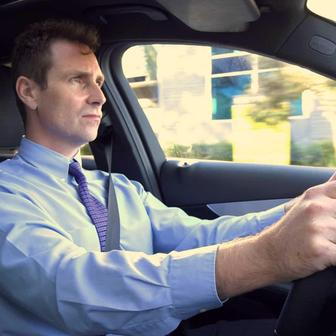

1. data/processed_images/traffic/Driving_Distraction_0/0000002.jpg
Rule: Road Condition
Label: Not Applicable ; Pred: Complied
Explanation: The man is driving a car and appears to be following the relevant road laws and advisory signs.

Enter feedback for rule 'Road Condition' (or press Enter to skip): If road condition is not shown in the image, the rule cannot be assessed
Nice feedback, the error is corrected!
Updated Final Feedback: 
Meta-rules: 
If road condition is not shown in the image, the rule cannot be assessed
Revising prior samples with updated prompt: ...


  0%|          | 0/1 [00:00<?, ?it/s]

1. data/processed_images/traffic/Driving_Distraction_0/0000002.jpg
Rule: Road Condition; Label: Not Applicable
Initial Pred: Complied  -->  Revised Pred: Not Applicable ✅
Initial Explanation: The man is driving a car and appears to be following the relevant road laws and advisory signs.
Revised Explanation: The image does not show the road conditions, so the rule cannot be assessed.

Batch 2 completed
Error in this batch:  1
Num corrections after feedback:  1
Num errors after prompt updates:  0
Accumulated corrections:  1
Accumulated errors:  0


  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...


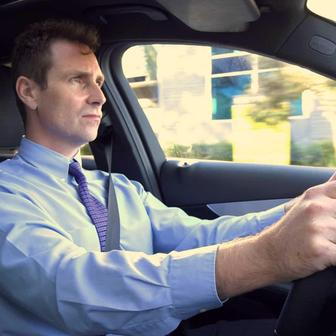

1. data/processed_images/traffic/Driving_Distraction_0/0000002.jpg
Rule: Traffic Rules
Label: Not Applicable ; Pred: Complied
Explanation: The man is driving a car and not violating any road rules.

Enter feedback for rule 'Traffic Rules' (or press Enter to skip): If traffic condition is not shown in the image, the rule cannot be assessed
Nice feedback, the error is corrected!
Updated Final Feedback: 
Meta-rules: 
If traffic condition is not shown in the image, the rule cannot be assessed
Revising prior samples with updated prompt: ...


  0%|          | 0/2 [00:00<?, ?it/s]

1. data/processed_images/traffic/Driving_Distraction_0/0000002.jpg
Rule: Road Condition; Label: Not Applicable
Initial Pred: Complied  -->  Revised Pred: Not Applicable ✅
Initial Explanation: The man is driving a car and appears to be following the relevant road laws and advisory signs.
Revised Explanation: The image does not show the road conditions, so the rule cannot be assessed.

2. data/processed_images/traffic/Driving_Distraction_0/0000002.jpg
Rule: Traffic Rules; Label: Not Applicable
Initial Pred: Complied  -->  Revised Pred: Not Applicable ✅
Initial Explanation: The man is driving a car and not violating any road rules.
Revised Explanation: The image does not show any traffic conditions or road signs that can be assessed according to the given rule set.

Batch 3 completed
Error in this batch:  1
Num corrections after feedback:  1
Num errors after prompt updates:  0
Accumulated corrections:  2
Accumulated errors:  0


  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 4 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  2
Accumulated errors:  0


...

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 25 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  2
Accumulated errors:  0


  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 26 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  2
Accumulated errors:  0


  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...


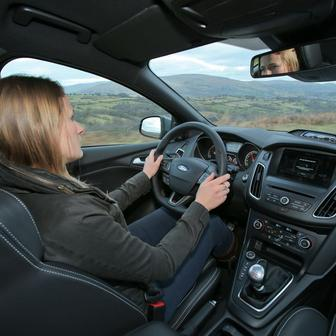

1. data/processed_images/traffic/Driving_Distraction_0/0000009.jpg
Rule: Road Condition
Label: Complied ; Pred: Not Applicable
Explanation: The image does not show the road conditions, so the rule cannot be assessed.

Enter feedback for rule 'Road Condition' (or press Enter to skip): If the image shows environmental condition, the rule can be assessed
Poor feedback. Please enter a new feedback for rule 'Road Condition' (or press Enter to skip): If the image shows environmental condition with clear weather, the rule is complied with


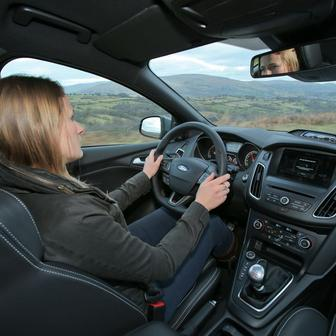

1. data/processed_images/traffic/Driving_Distraction_0/0000009.jpg
Rule: Road Condition
Label: Complied ; Pred: Not Applicable
Explanation: The image does not show the road conditions, so the rule cannot be assessed.

Nice feedback, the error is corrected!
Updated Final Feedback: 
Meta-rules: 
If road condition is not shown in the image, the rule cannot be assessed
If the image shows environmental condition with clear weather, the rule is complied with
Revising prior samples with updated prompt: ...


  0%|          | 0/3 [00:00<?, ?it/s]

1. data/processed_images/traffic/Driving_Distraction_0/0000002.jpg
Rule: Road Condition; Label: Not Applicable
Initial Pred: Complied  -->  Revised Pred: Complied ❌
Initial Explanation: The man is driving a car and appears to be following the relevant road laws and advisory signs.
Revised Explanation: The man is driving a car on a highway, which is a relevant factor for the rule. The image shows a clear day, which is another relevant factor for the rule. The man is wearing a tie, which is not a relevant factor for the rule. Therefore, the rule is complied with.

2. data/processed_images/traffic/Driving_Distraction_0/0000002.jpg
Rule: Traffic Rules; Label: Not Applicable
Initial Pred: Complied  -->  Revised Pred: Not Applicable ✅
Initial Explanation: The man is driving a car and not violating any road rules.
Revised Explanation: The image does not show any traffic conditions or road signs that can be assessed according to the given rule set.

3. data/processed_images/traffic/Driving_Dis

  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 28 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  3
Accumulated errors:  1


...

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 47 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  3
Accumulated errors:  1


  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 48 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  3
Accumulated errors:  1


  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 49 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  3
Accumulated errors:  1
Total execution time: 3 min 15 sec


In [ ]:
init_feedbacks = defaultdict(list) # empty
early_stop = 50
feedback_iteration = "feedback_0"
df_results, df_checkpoints,feedbacks = main(datasets, image_cache, model_name, template_id, domain, run_feedback_loop, init_feedbacks, feedback_iteration, batch_size, early_stop)

In [ ]:
feedbacks # check feedback provided

defaultdict(list,
            {'Road Condition': ['If road condition is not shown in the image, the rule cannot be assessed'],
             'Traffic Rules': ['If traffic condition is not shown in the image, the rule cannot be assessed']})

Running llava with on train_df set


  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 0 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  0
Accumulated errors:  0


  0%|          | 0/1 [00:00<?, ?it/s]

...

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 25 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  0
Accumulated errors:  0


  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 26 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  0
Accumulated errors:  0


  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...


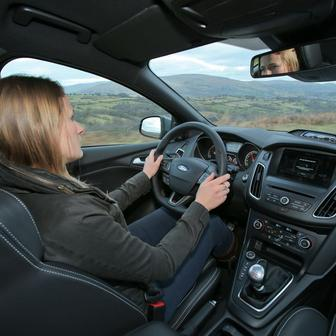

1. data/processed_images/traffic/Driving_Distraction_0/0000009.jpg
Rule: Road Condition
Label: Complied ; Pred: Not Applicable
Explanation: The image does not show the road conditions, so the rule cannot be assessed.

Nice feedback, the error is corrected!
Updated Final Feedback: 
Meta-rules: 
If road condition is not shown in the image, the rule cannot be assessed
If the image shows clear weather, the rule is complied with
Revising prior samples with updated prompt: ...


  0%|          | 0/1 [00:00<?, ?it/s]

1. data/processed_images/traffic/Driving_Distraction_0/0000009.jpg
Rule: Road Condition; Label: Complied
Initial Pred: Not Applicable  -->  Revised Pred: Complied ✅
Initial Explanation: The image does not show the road conditions, so the rule cannot be assessed.
Revised Explanation: The woman is driving a car on a road, which is a relevant factor for the rule. The image shows a clear day, which is another relevant factor for the rule. The woman is wearing a brown jacket, which is not a relevant factor for the rule. The car is not a hazardous vehicle, which is another relevant factor for the rule. The woman is not using the car in a hazardous area, which is another relevant factor for the rule. The woman is not driving under the influence of alcohol or drugs, which is another relevant factor for the rule. The woman is not speeding, which is another relevant factor for the rule. The woman is not using her phone while driving, which is another relevant factor for the rule. The woman is no

  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 28 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  1
Accumulated errors:  0


...

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 47 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  1
Accumulated errors:  0


  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 48 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  1
Accumulated errors:  0


  0%|          | 0/1 [00:00<?, ?it/s]

Filtering error samples: ...
All good! No weak samples to collect feedback from.
Batch 49 completed
Error in this batch:  0
Num corrections after feedback:  0
Num errors after prompt updates:  0
Accumulated corrections:  1
Accumulated errors:  0
Total execution time: 3 min 30 sec


In [17]:
init_feedbacks = feedbacks # edit/ use returned feedback list to run again
feedback_iteration = "feedback_1"
df_results, df_checkpoints,feedbacks = main(datasets, image_cache, model_name, template_id, domain, run_feedback_loop, init_feedbacks, feedback_iteration, batch_size, early_stop)

In [18]:
feedbacks # check feedback provided

defaultdict(list,
            {'Road Condition': ['If road condition is not shown in the image, the rule cannot be assessed',
              'If the image shows clear weather, the rule is complied with'],
             'Traffic Rules': ['If traffic condition is not shown in the image, the rule cannot be assessed']})